Ewaluacja dwóch modeli na zbiorze SUN:
ResNet18 (Places365)
CLIP ViT-B/32

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from PIL import Image
import scipy.io

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms as trn
from torch.utils.data import DataLoader

import clip  

from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import joblib
from tqdm import tqdm

from data_loading import load_sun_data
from dataloaders import SUNDataset, create_sun_dataloader
from utils import tqdm_joblib

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## 1. Wczytanie danych 


In [2]:
df_sun, attributes_list, attr_cols = load_sun_data(base_path='data/SUN/SUNAttributeDB', threshold=0.5)

print(f'Obrazy: {len(df_sun)}, atrybuty: {len(attr_cols)}')
df_sun.head(3)

Obrazy: 14340, atrybuty: 102


,image_id,file_path,class_id,sailing/ boating,driving,biking,transporting things or people,sunbathing,vacationing/ touring,hiking,...,far-away horizon,no horizon,rugged scene,mostly vertical components,mostly horizontal components,symmetrical,cluttered space,scary,soothing,stressful
0,1,a/abbey/sun_aakbdcgfpksytcwj.jpg,a,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2,a/abbey/sun_aaoktempcmudsvna.jpg,a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,a/abbey/sun_abegcweqnetpdlrh.jpg,a,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# tqdm_joblib jest zaimportowany z modułu utils
# Służy do wyświetlania paska postępu przy gleichoczesnym treningiem
print("tqdm_joblib dostępny z modułu utils")

tqdm_joblib dostępny z modułu utils


### Dataloader

In [4]:
# SUNDataset jest zaimportowany z modułu dataloaders
# Funkcja create_sun_dataloader() tworzy DataLoader z odpowiednimi parametrami
print("SUNDataset i create_sun_dataloader dostępne z modułu dataloaders")

SUNDataset i create_sun_dataloader dostępne z modułu dataloaders


## 3. ResNet18 (Places365) 
Model pochodzi z: https://github.com/CSAILVision/places365  

In [5]:
model_file = 'models/resnet18_places365.pth'

conv_model = models.resnet18(num_classes=365)
checkpoint = torch.load(model_file, map_location=lambda storage, loc: storage)
state_dict = {str.replace(k, 'module.', ''): v for k, v in checkpoint['state_dict'].items()}
conv_model.load_state_dict(state_dict)

conv_model.fc = nn.Identity()  # cechy 512-d
conv_model = conv_model.to(DEVICE).eval()

centre_crop = trn.Compose([
    trn.Resize((256, 256)),
    trn.CenterCrop(224),
    trn.ToTensor(),
    trn.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print('ResNet18/Places365 załadowany. Wymiar cech: 512')

C:\Users\Admin\AppData\Local\Temp\ipykernel_54208\2758433093.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_file, map_location=lambda stor

ResNet18/Places365 załadowany. Wymiar cech: 512


In [6]:
dataloader_resnet = create_sun_dataloader(
    df=df_sun, 
    img_dir='data/SUN/images/', 
    transform=centre_crop,
    attr_cols=attr_cols,
    batch_size=16,
    num_workers=0
)

features_conv, labels_conv, paths_conv = [], [], []

conv_model.eval()
with torch.no_grad():
    for batch_imgs, batch_labels, batch_paths in tqdm(dataloader_resnet, desc='ResNet18 features (Batched)'):
        batch_imgs = batch_imgs.to(DEVICE)
        batch_feats = conv_model(batch_imgs).cpu().numpy()
        features_conv.extend(batch_feats)
        labels_conv.extend(batch_labels.numpy())
        paths_conv.extend(batch_paths)

X_conv = np.array(features_conv)
y_conv = np.array(labels_conv)
paths_conv = np.array(paths_conv)
print(f'X_conv: {X_conv.shape}, y_conv: {y_conv.shape}')

ResNet18 features (Batched): 100%|██████████| 897/897 [02:11<00:00,  6.84it/s]

X_conv: (14340, 512), y_conv: (14340, 102)


In [7]:
X_tr_c, X_te_c, y_tr_c, y_te_c, paths_tr_c, paths_te_c = train_test_split(
    X_conv, y_conv, paths_conv, test_size=0.2, random_state=42
)

clf_conv = MultiOutputClassifier(LogisticRegression(max_iter=1000), n_jobs=-1)
with tqdm_joblib(tqdm(desc=f'ResNet18 – trening ({len(attr_cols)} atrybutów)', total=len(attr_cols))):
    clf_conv.fit(X_tr_c, y_tr_c)

y_pred_c  = clf_conv.predict(X_te_c)
y_proba_c = np.column_stack([p[:, 1] for p in clf_conv.predict_proba(X_te_c)])

results_conv = {
    'Exact Match Acc': accuracy_score(y_te_c, y_pred_c),
    'F1 Macro':        f1_score(y_te_c, y_pred_c, average='macro'),
    'ROC AUC Macro':   roc_auc_score(y_te_c, y_proba_c, average='macro'),
}

print('\n====== ResNet18 (Places365) + LogReg ======')
for k, v in results_conv.items():
    print(f'  {k}: {v:.4f}')

ResNet18 – trening (102 atrybutów):   0%|          | 0/102 [00:00<?, ?it/s]

ResNet18 – trening (102 atrybutów): 100%|██████████| 102/102 [00:41<00:00,  7.15it/s]


====== ResNet18 (Places365) + LogReg ======
  Exact Match Acc: 0.0164
  F1 Macro: 0.4622
  ROC AUC Macro: 0.9195


### Wizualizacja błędów – ResNet18

ResNet18 – trening (102 atrybutów): 100%|██████████| 102/102 [00:52<00:00,  1.94it/s]

Znaleziono 2821 obrazów z przynajmniej 1 błędem. Wyświetlam 2 przykłady...


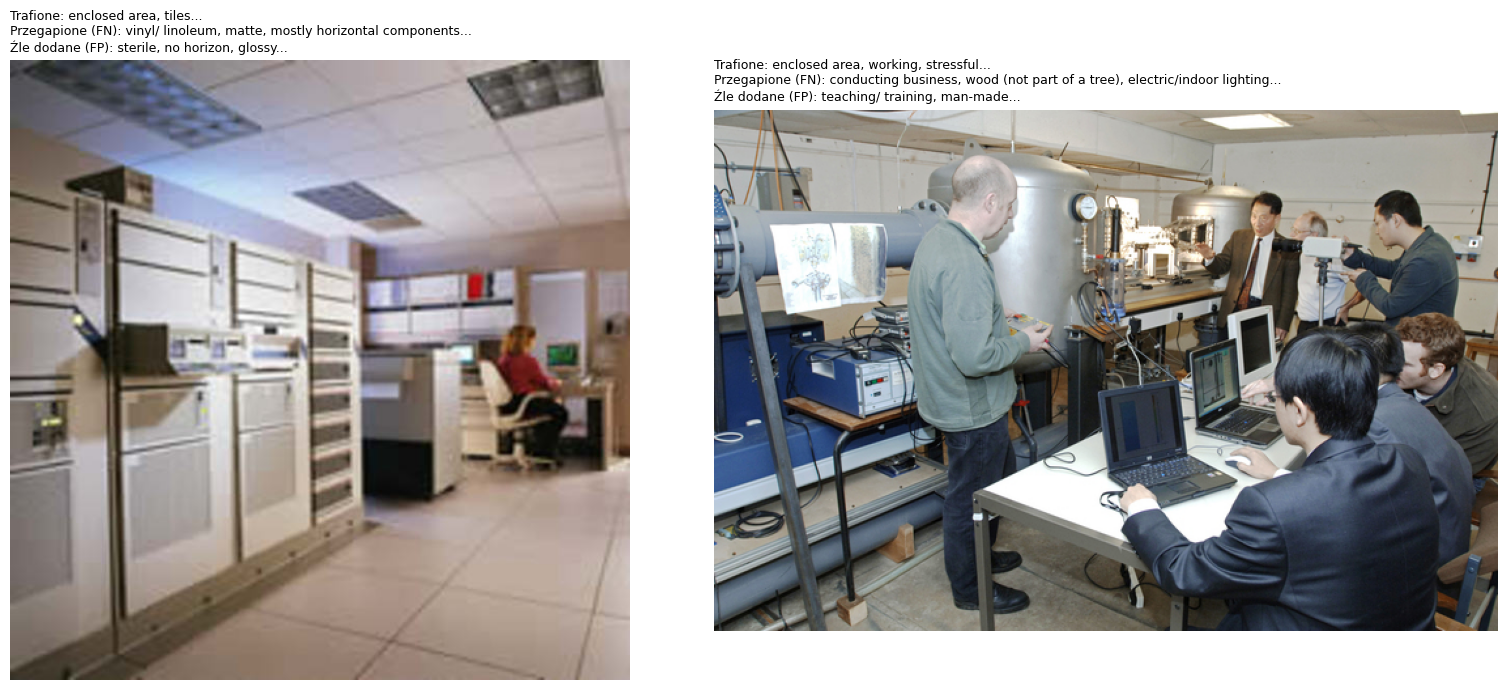

In [8]:
errors_per_sample = np.sum(y_pred_c != y_te_c, axis=1)
incorrect_indices = np.where(errors_per_sample > 0)[0]

if len(incorrect_indices) > 0:
    print(f'Znaleziono {len(incorrect_indices)} obrazów z przynajmniej 1 błędem. Wyświetlam 2 przykłady...')
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for i, idx in enumerate(incorrect_indices[:2]):
        true_attrs  = set([attr_cols[j] for j, v in enumerate(y_te_c[idx])  if v == 1])
        pred_attrs  = set([attr_cols[j] for j, v in enumerate(y_pred_c[idx]) if v == 1])
        fn = true_attrs - pred_attrs
        fp = pred_attrs - true_attrs
        ok = true_attrs & pred_attrs
        try:
            img = Image.open(paths_te_c[idx]).convert('RGB')
            axes[i].imshow(img)
            axes[i].set_title(
                f'Trafione: {", ".join(list(ok)[:3])}...\n'
                f'Przegapione (FN): {", ".join(list(fn)[:3])}...\n'
                f'Źle dodane (FP): {", ".join(list(fp)[:3])}...',
                fontsize=9, loc='left'
            )
            axes[i].axis('off')
        except Exception as e:
            print(f'Błąd wczytywania: {e}')
    plt.tight_layout()
    plt.show()
else:
    print('Model przewidział wszystkie atrybuty perfekcyjnie!')

## 4. CLIP ViT-B/32 

In [9]:
clip_model, clip_preprocess = clip.load('ViT-B/32', device=DEVICE)
clip_model.eval()
print('CLIP załadowany. Wymiar embeddingu:', clip_model.visual.output_dim)

100%|███████████████████████████████████████| 338M/338M [03:50<00:00, 1.54MiB/s]


CLIP załadowany. Wymiar embeddingu: 512


In [10]:
dataloader_clip = create_sun_dataloader(
    df=df_sun, 
    img_dir='data/SUN/images/', 
    transform=clip_preprocess,
    attr_cols=attr_cols,
    batch_size=64,
    num_workers=4
)

features_clip, labels_clip, paths_clip_arr = [], [], []

with torch.no_grad():
    for batch_imgs, batch_labels, batch_paths in tqdm(dataloader_clip, desc='CLIP features (Batched)'):
        batch_imgs = batch_imgs.to(DEVICE)

        batch_feats = clip_model.encode_image(batch_imgs).cpu().float().numpy()
        
        features_clip.extend(batch_feats)
        labels_clip.extend(batch_labels.numpy())
        paths_clip_arr.extend(batch_paths)

X_clip = np.array(features_clip)
y_clip = np.array(labels_clip)
paths_clip_arr = np.array(paths_clip_arr)
print(f'X_clip: {X_clip.shape}, y_clip: {y_clip.shape}')

CLIP features (Batched): 100%|██████████| 225/225 [00:40<00:00,  5.53it/s]

X_clip: (14340, 512), y_clip: (14340, 102)


## 4a. CLIP – Linear Probe

In [11]:
X_tr_cl, X_te_cl, y_tr_cl, y_te_cl, paths_tr_cl, paths_te_cl = train_test_split(
    X_clip, y_clip, paths_clip_arr, test_size=0.2, random_state=42
)

clf_clip = MultiOutputClassifier(LogisticRegression(max_iter=1000), n_jobs=-1)
with tqdm_joblib(tqdm(desc=f'CLIP linear probe ({len(attr_cols)} atrybutów)', total=len(attr_cols))):
    clf_clip.fit(X_tr_cl, y_tr_cl)

y_pred_cl  = clf_clip.predict(X_te_cl)
y_proba_cl = np.column_stack([p[:, 1] for p in clf_clip.predict_proba(X_te_cl)])

results_clip_probe = {
    'Exact Match Acc': accuracy_score(y_te_cl, y_pred_cl),
    'F1 Macro':        f1_score(y_te_cl, y_pred_cl, average='macro'),
    'ROC AUC Macro':   roc_auc_score(y_te_cl, y_proba_cl, average='macro'),
}

print('\n====== CLIP ViT-B/32 + Linear Probe ======')
for k, v in results_clip_probe.items():
    print(f'  {k}: {v:.4f}')

CLIP linear probe (102 atrybutów):   0%|          | 0/102 [00:00<?, ?it/s]

CLIP linear probe (102 atrybutów): 100%|██████████| 102/102 [00:21<00:00,  8.23it/s]


====== CLIP ViT-B/32 + Linear Probe ======
  Exact Match Acc: 0.0164
  F1 Macro: 0.4694
  ROC AUC Macro: 0.9299


## 4b. CLIP – Zero-Shot detekcja atrybutów SUN

Dla każdego atrybutu tworzymy dwa prompty:
```
positive = "a photo of a place that is open area"
negative = "a photo of a place that is not open area"
```
Softmax nad podobieństwem kosinusowym daje prawdopodobieństwo obecności atrybutu.

In [12]:

pos_prompts = [f'a photo of a place that is {attr}' for attr in attr_cols]
neg_prompts = [f'a photo of a place that is not {attr}' for attr in attr_cols]

with torch.no_grad():
    pos_emb = clip_model.encode_text(clip.tokenize(pos_prompts, truncate=True).to(DEVICE)).float()
    neg_emb = clip_model.encode_text(clip.tokenize(neg_prompts, truncate=True).to(DEVICE)).float()
    pos_emb = pos_emb / pos_emb.norm(dim=-1, keepdim=True)
    neg_emb = neg_emb / neg_emb.norm(dim=-1, keepdim=True)


In [13]:
idx_all = np.arange(len(df_sun))
_, idx_test = train_test_split(idx_all, test_size=0.2, random_state=42)


test_df = df_sun.iloc[idx_test].reset_index(drop=True)

dataset_test = SUNDataset(
    df=test_df, 
    img_dir='data/SUN/images/', 
    transform=clip_preprocess,
    attr_cols=attr_cols
)

dataloader_test = DataLoader(dataset_test, batch_size=64, shuffle=False, num_workers=4)

zs_probs = []

with torch.no_grad():
    for batch_imgs, batch_labels, _ in tqdm(dataloader_test, desc='CLIP zero-shot scoring (Batched)'):
        batch_imgs = batch_imgs.to(DEVICE)
    
        img_feat = clip_model.encode_image(batch_imgs).float()
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)

        sim_pos = img_feat @ pos_emb.T
        sim_neg = img_feat @ neg_emb.T
        
        probs = torch.stack([sim_pos, sim_neg], dim=-1).mul(100).softmax(dim=-1)[:, :, 0]
        zs_probs.extend(probs.cpu().numpy())

zs_probs = np.array(zs_probs)
zs_preds = (zs_probs >= 0.5).astype(int)
y_te_zs  = y_clip[idx_test]

results_clip_zs = {
    'Exact Match Acc': accuracy_score(y_te_zs, zs_preds),
    'F1 Macro':        f1_score(y_te_zs, zs_preds, average='macro'),
    'ROC AUC Macro':   roc_auc_score(y_te_zs, zs_probs, average='macro'),
}

print('\n====== CLIP Zero-Shot ======')
for k, v in results_clip_zs.items():
    print(f'  {k}: {v:.4f}')

CLIP zero-shot scoring (Batched): 100%|██████████| 45/45 [00:17<00:00,  2.64it/s]


====== CLIP Zero-Shot ======
  Exact Match Acc: 0.0000
  F1 Macro: 0.1867
  ROC AUC Macro: 0.7218


## 5. Porównanie modeli

                               Exact Match Acc  F1 Macro  ROC AUC Macro
Model                                                                  
ResNet18 (Places365) + LogReg         0.016388  0.462216       0.919454
CLIP ViT-B/32 + Linear Probe          0.016388  0.469377       0.929851
CLIP Zero-Shot                        0.000000  0.186694       0.721800


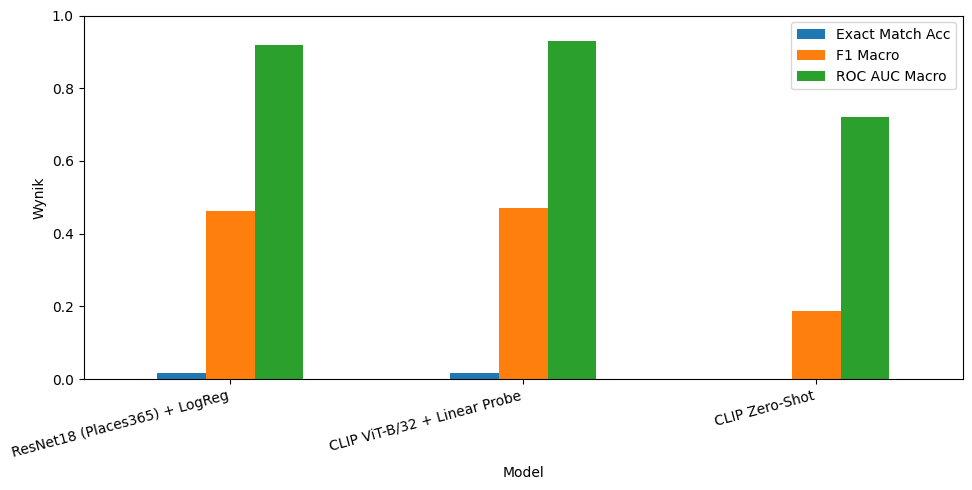

In [14]:
comparison = pd.DataFrame({
    'Model': ['ResNet18 (Places365) + LogReg', 'CLIP ViT-B/32 + Linear Probe', 'CLIP Zero-Shot'],
    'Exact Match Acc': [results_conv['Exact Match Acc'],       results_clip_probe['Exact Match Acc'],    results_clip_zs['Exact Match Acc']],
    'F1 Macro':        [results_conv['F1 Macro'],              results_clip_probe['F1 Macro'],           results_clip_zs['F1 Macro']],
    'ROC AUC Macro':   [results_conv['ROC AUC Macro'],         results_clip_probe['ROC AUC Macro'],      results_clip_zs['ROC AUC Macro']],
}).set_index('Model')

print(comparison.to_string())

comparison.plot(kind='bar', figsize=(10, 5), ylim=(0, 1))
plt.ylabel('Wynik')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## 6. Per-atrybut analiza: CLIP zero-shot vs ResNet18

In [15]:
auc_conv_per = [roc_auc_score(y_te_c[:, j],  y_proba_c[:, j])  for j in range(len(attr_cols))]
auc_probe_per = [roc_auc_score(y_te_cl[:, j], y_proba_cl[:, j]) for j in range(len(attr_cols))]
auc_zs_per   = [roc_auc_score(y_te_zs[:, j], zs_probs[:, j])   for j in range(len(attr_cols))]

per_attr = pd.DataFrame({
    'attr':           attr_cols,
    'AUC_ResNet18':   auc_conv_per,
    'AUC_CLIP_Probe': auc_probe_per,
    'AUC_CLIP_ZS':    auc_zs_per,
})
per_attr['best'] = per_attr[['AUC_ResNet18', 'AUC_CLIP_Probe', 'AUC_CLIP_ZS']].idxmax(axis=1)

print('Top-10 atrybutów gdzie CLIP Zero-Shot > obu pozostałych:')
zs_wins = per_attr[per_attr['best'] == 'AUC_CLIP_ZS'].nlargest(10, 'AUC_CLIP_ZS')
print(zs_wins[['attr', 'AUC_ResNet18', 'AUC_CLIP_Probe', 'AUC_CLIP_ZS']].to_string(index=False))

print('\nTop-10 atrybutów gdzie CLIP Probe > obu pozostałych:')
probe_wins = per_attr[per_attr['best'] == 'AUC_CLIP_Probe'].nlargest(10, 'AUC_CLIP_Probe')
print(probe_wins[['attr', 'AUC_ResNet18', 'AUC_CLIP_Probe', 'AUC_CLIP_ZS']].to_string(index=False))

print('\nTop-10 atrybutów gdzie ResNet18 > obu pozostałych:')
res_wins = per_attr[per_attr['best'] == 'AUC_ResNet18'].nlargest(10, 'AUC_ResNet18')
print(res_wins[['attr', 'AUC_ResNet18', 'AUC_CLIP_Probe', 'AUC_CLIP_ZS']].to_string(index=False))

Top-10 atrybutów gdzie CLIP Zero-Shot > obu pozostałych:
   attr  AUC_ResNet18  AUC_CLIP_Probe  AUC_CLIP_ZS
flowers      0.973266        0.972587      0.98395

Top-10 atrybutów gdzie CLIP Probe > obu pozostałych:
                  attr  AUC_ResNet18  AUC_CLIP_Probe  AUC_CLIP_ZS
              railroad      0.998245        0.999076     0.975781
                  fire      0.990079        0.998164     0.619886
                   ice      0.991771        0.996077     0.963699
                  snow      0.992670        0.996070     0.977203
                 smoke      0.934607        0.991957     0.913767
                sports      0.969043        0.987040     0.898110
      medical activity      0.984558        0.986888     0.887482
      sailing/ boating      0.981912        0.985805     0.788460
constructing/ building      0.968823        0.984278     0.860772
             competing      0.964383        0.982593     0.917062

Top-10 atrybutów gdzie ResNet18 > obu pozostałych:
         

## 7. Sprawdzenie już hierarchiczności


Z `datasets_tests.ipynb` mamy `P(man-made | shingles) ≈ 0.97`.  
Czy widać to w przestrzeni CLIP?

Prompty:
  [0] a photo of a place that is shingles
  [1] a photo of a place that is man-made
  [2] a photo of a place that is shingles and man-made
  [3] a photo of an outdoor natural place



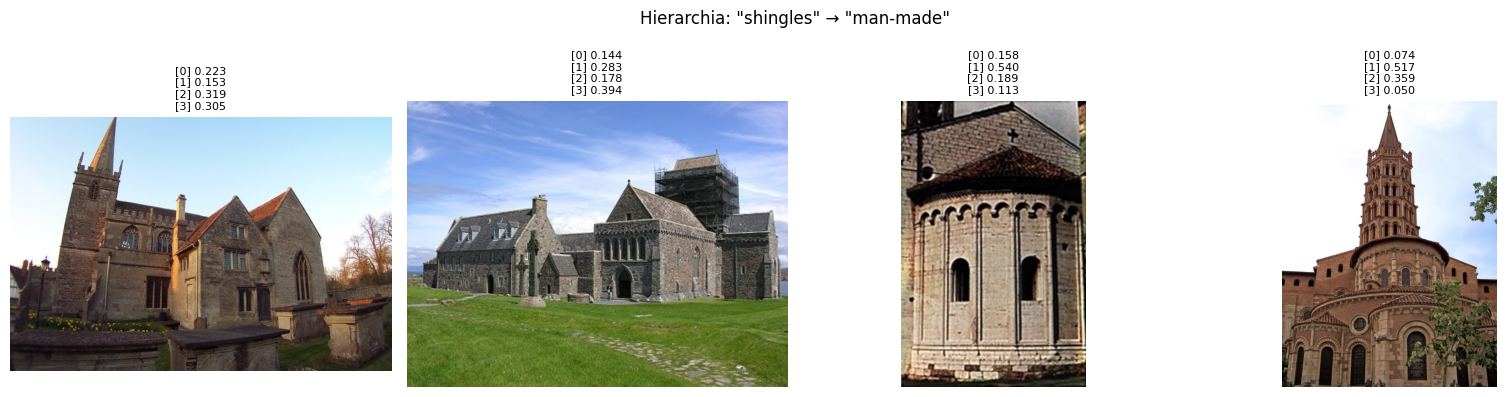

In [16]:
CONCEPT_A = 'shingles'   
CONCEPT_B = 'man-made'        

prompts = [
    f'a photo of a place that is {CONCEPT_A}',
    f'a photo of a place that is {CONCEPT_B}',
    f'a photo of a place that is {CONCEPT_A} and {CONCEPT_B}',
    f'a photo of an outdoor natural place',
]

with torch.no_grad():
    tokens  = clip.tokenize(prompts, truncate=True).to(DEVICE)
    text_fs = clip_model.encode_text(tokens).float()
    text_fs = text_fs / text_fs.norm(dim=-1, keepdim=True)

col_a = CONCEPT_A if CONCEPT_A in df_sun.columns else attr_cols[0]
sample_rows = df_sun[df_sun[col_a] == 1].head(4)

print(f'Prompty:')
for i, p in enumerate(prompts):
    print(f'  [{i}] {p}')
print()

fig, axes = plt.subplots(1, len(sample_rows), figsize=(16, 4))
with torch.no_grad():
    for ax, (_, row) in zip(axes, sample_rows.iterrows()):
        img_path = os.path.join('data/SUN/images/', str(row['file_path']))
        img  = Image.open(img_path).convert('RGB')
        inp  = clip_preprocess(img).unsqueeze(0).to(DEVICE)
        feat = clip_model.encode_image(inp).squeeze().float()
        feat = feat / feat.norm()

        sims  = (feat @ text_fs.T).cpu().numpy()
        probs = np.exp(sims * 100) / np.exp(sims * 100).sum()

        ax.imshow(img)
        ax.set_title(
            '\n'.join([f'[{i}] {p:.3f}' for i, p in enumerate(probs)]),
            fontsize=8
        )
        ax.axis('off')

plt.suptitle(f'Hierarchia: "{CONCEPT_A}" → "{CONCEPT_B}"', fontsize=12)
plt.tight_layout()
plt.show()

Widzi dosyć słabo, może przez to, że "shingles" to też półpasiec?